# Week 6 — Autoencoder for Image Denoising

## Project Title 

### Autoencoder for Image Denoising

The goal of this project is to train an autoencoder that can remove artificial noise from handwritten digit images.

The model will learn from noisy images as input and clean images as the target. At the end, we will compare the original, noisy, and denoised images.

#### 1. Import Required Libraries

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models

#### 2. Checking the Dataset

The training and testing folders contain separate images for the two parts of the dataset. Each digit has its own folder from 0 to 9.

First, I will check whether both folders are available before loading the images.

In [2]:
train_dir = "training"
test_dir = "testing"

print("Training folder exists:", os.path.exists(train_dir))
print("Testing folder exists:", os.path.exists(test_dir))

Training folder exists: True
Testing folder exists: True


### 3. Load and Preprocess the Dataset

## Loading Training Images

The images are stored inside folders based on their digit labels. Since the autoencoder does not need the digit labels, I will load only the images.

The images are resized to 28 × 28 pixels and converted into grayscale.

In [3]:
IMG_SIZE = (28, 28)
BATCH_SIZE = 128

train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    labels=None,
    color_mode="grayscale",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=42
)

print("Training dataset loaded successfully.")

Found 60000 files.
Training dataset loaded successfully.


### Load Testing Images

The testing images are loaded separately. These images will be used later to check how well the trained autoencoder removes noise from unseen data.

In [4]:
test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    labels=None,
    color_mode="grayscale",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Testing dataset loaded successfully.")

Found 10000 files.
Testing dataset loaded successfully.


### 4. Normalize the Images

The pixel values of an image normally range from 0 to 255. I will convert them to a range between 0 and 1.

This makes the data easier for the neural network to process during training.

In [5]:
def normalize_images(images):
    images = tf.cast(images, tf.float32)
    images = images / 255.0
    return images


train_dataset = train_dataset.map(normalize_images)
test_dataset = test_dataset.map(normalize_images)

print("Images normalized successfully.")

Images normalized successfully.


### 5. Check Image Shape
#### Checking the Image Data

Before creating the model, I will check the shape of one batch of images to make sure the preprocessing worked correctly.

In [6]:
sample_images = next(iter(train_dataset))

print("Image batch shape:", sample_images.shape)
print("Minimum pixel value:", tf.reduce_min(sample_images).numpy())
print("Maximum pixel value:", tf.reduce_max(sample_images).numpy())

Image batch shape: (128, 28, 28, 1)
Minimum pixel value: 0.0
Maximum pixel value: 1.0


### 6. Display Original Images
#### Viewing Original Images
Display a few images from the training data to make sure the images have been loaded correctly.

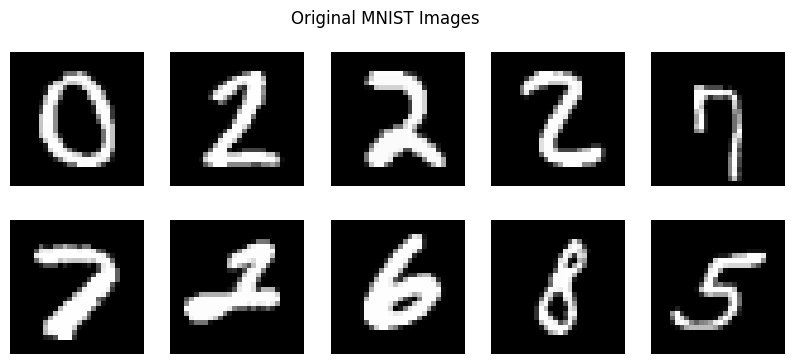

In [7]:
plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(sample_images[i].numpy().squeeze(), cmap="gray")
    plt.axis("off")

plt.suptitle("Original MNIST Images")
plt.show()

### 7.Add Artificial Noise
Create Noisy Images
#### Adding Noise to Images

To train a denoising autoencoder, the model needs to see both noisy and clean versions of the same image.
Adding random Gaussian noise to the original images. The noisy image will be given to the model as input, while the original clean image will be used as the target. 

In [8]:
noise_factor = 0.4

def add_noise(images):
    noise = tf.random.normal(
        shape=tf.shape(images),
        mean=0.0,
        stddev=noise_factor
    )

    noisy_images = images + noise
    noisy_images = tf.clip_by_value(noisy_images, 0.0, 1.0)

    return noisy_images

### 8. Test the Noise
#### Checking the Added Noise

Before training the model, I will compare a few clean images with their noisy versions. This helps confirm that the noise level is reasonable.

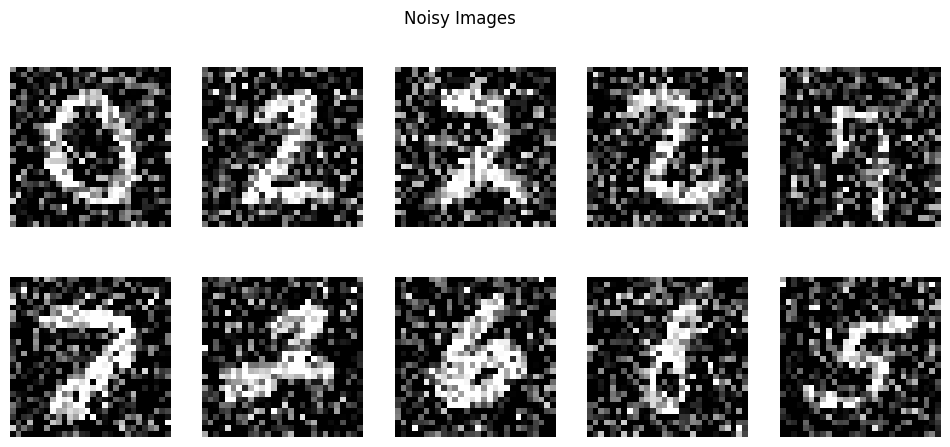

In [9]:
noisy_sample = add_noise(sample_images)

plt.figure(figsize=(12, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(noisy_sample[i].numpy().squeeze(), cmap="gray")
    plt.axis("off")

plt.suptitle("Noisy Images")
plt.show()

### 9. Prepare Training Data
Create Noisy Training Pipeline
#### Preparing Data for the Autoencoder

The autoencoder will receive noisy images and try to reconstruct the original clean images.

So the training relationship will be:

**Noisy image → Autoencoder → Clean image** 

In [10]:
def prepare_autoencoder_data(images):
    noisy_images = add_noise(images)
    return noisy_images, images


train_autoencoder = train_dataset.map(
    prepare_autoencoder_data
)

test_autoencoder = test_dataset.map(
    prepare_autoencoder_data
)

### 10. Build the Denoising Autoencoder
#### Building the Autoencoder

An autoencoder has two main parts:

- **Encoder:** compresses the image into a smaller representation.
- **Decoder:** reconstructs the image from that representation.

For this project, the encoder uses convolution and pooling to learn important image patterns, while the decoder uses upsampling to bring the image back to its original size.

In [11]:
autoencoder = models.Sequential([

    # Encoder
    layers.Input(shape=(28, 28, 1)),

    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2), padding="same"),

    layers.Conv2D(16, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2), padding="same"),

    # Decoder
    layers.Conv2D(16, (3, 3), activation="relu", padding="same"),
    layers.UpSampling2D((2, 2)),

    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.UpSampling2D((2, 2)),

    layers.Conv2D(
        1,
        (3, 3),
        activation="sigmoid",
        padding="same"
    )
])

autoencoder.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 16)       │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,193 (47.63 KB)

 Trainable params: 12,193 (47.63 KB)

 Non-trainable params: 0 (0.00 B)

### 11. Compile the Model

The autoencoder is trained using the Adam optimizer. Using Mean Squared Error as the loss because the task is to reconstruct pixel values as closely as possible to the original image.

In [12]:
autoencoder.compile(
    optimizer="adam",
    loss="mse"
)

print("Autoencoder compiled successfully.")

Autoencoder compiled successfully.


### 12. Train the Autoencoder

The model now learns to reconstruct clean images from noisy inputs.

During training, the loss should gradually decrease, which indicates that the reconstructed images are becoming closer to the original images.

In [13]:
history = autoencoder.fit(
    train_autoencoder,
    validation_data=test_autoencoder,
    epochs=20
)

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 27s 54ms/step - loss: 0.1139 - val_loss: 0.1140
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 17s 36ms/step - loss: 0.1120 - val_loss: 0.1140
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 18s 37ms/step - loss: 0.1120 - val_loss: 0.1140
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 18s 38ms/step - loss: 0.1120 - val_loss: 0.1140
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 41s 87ms/step - loss: 0.1120 - val_loss: 0.1140
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 28s 59ms/step - loss: 0.1120 - val_loss: 0.1140
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 48s 101ms/step - loss: 0.1120 - val_loss: 0.1140
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 16s 35ms/step - loss: 0.1120 - val_loss: 0.1140
Epoch 9/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 33s 70ms/step - loss: 0.1120 - val_loss: 0.1140
Epoch 10/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 24s 51ms/step - loss: 0.1120 - val_loss: 0.1140
Epoch 11/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 17s 36ms/step - loss: 0.1120 - val_loss: 0.1140
Epoch 12/20
469/469 ━━━━━━━━━

### 13.Plot Training Loss
Training Curve
#### Training Performance

The loss curve shows how the reconstruction error changes during training.

A decreasing training and validation loss indicates that the autoencoder is learning to reconstruct the clean images from noisy inputs.

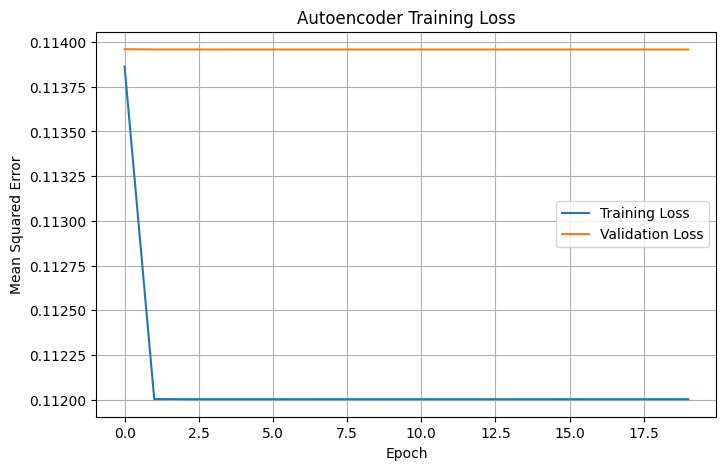

In [14]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Autoencoder Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")
plt.legend()
plt.grid(True)

plt.show()

### 14. Get Test Images
#### Denoising Test Images

After training, Using the model on test images that it has not seen during training.

The output of the autoencoder should be a cleaner version of the noisy input.

In [15]:
clean_test_images = []
noisy_test_images = []

for images in test_dataset.take(2):
    noisy_images = add_noise(images)

    clean_test_images.append(images.numpy())
    noisy_test_images.append(noisy_images.numpy())

clean_test_images = np.concatenate(clean_test_images)
noisy_test_images = np.concatenate(noisy_test_images)

print("Test images prepared:", clean_test_images.shape)

Test images prepared: (256, 28, 28, 1)


### 15. Reconstruct the Images
#### Generating Denoised Images

The trained autoencoder takes the noisy images as input and produces reconstructed images. These reconstructed images are the denoised results.

In [16]:
denoised_images = autoencoder.predict(
    noisy_test_images,
    verbose=0
)

print("Denoised images generated successfully.")

Denoised images generated successfully.


### 16. Compare Original, Noisy and Denoised
#### Original vs Noisy vs Denoised

This comparison shows whether the autoencoder has actually learned to remove noise.

The first row contains the original clean images, the second row contains the noisy versions, and the third row contains the reconstructed images produced by the autoencoder.

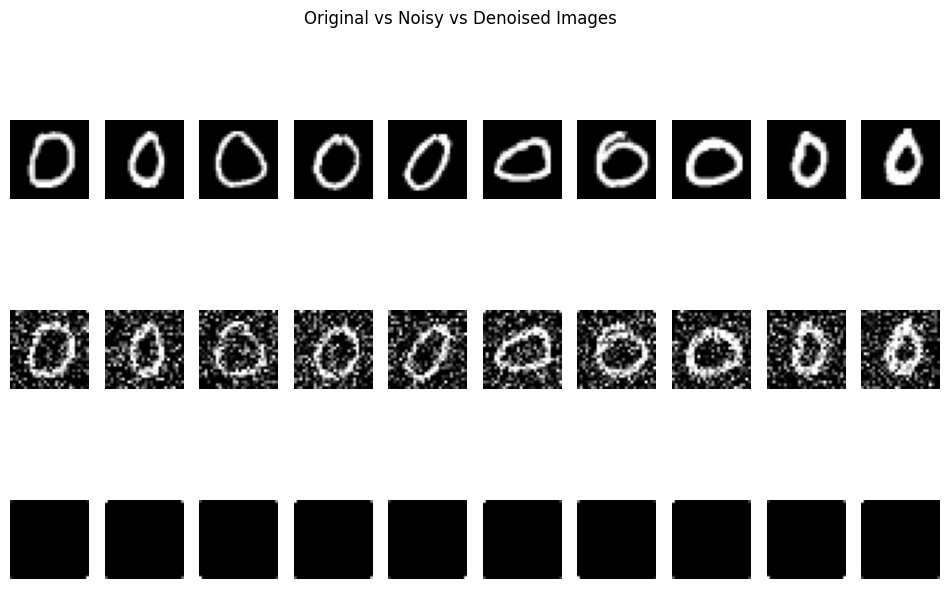

In [17]:
plt.figure(figsize=(12, 7))

for i in range(10):

    # Original
    plt.subplot(3, 10, i + 1)
    plt.imshow(clean_test_images[i].squeeze(), cmap="gray")
    plt.axis("off")

    # Noisy
    plt.subplot(3, 10, i + 11)
    plt.imshow(noisy_test_images[i].squeeze(), cmap="gray")
    plt.axis("off")

    # Denoised
    plt.subplot(3, 10, i + 21)
    plt.imshow(denoised_images[i].squeeze(), cmap="gray")
    plt.axis("off")

plt.suptitle("Original vs Noisy vs Denoised Images")

plt.show()

### 17. MSE Comparison
#### Denoising Performance

To get a simple numerical idea of the reconstruction quality, Comparing the Mean Squared Error of the noisy images and the denoised images against the original images.

A lower MSE means the image is closer to the clean original.

In [18]:
noisy_mse = np.mean(
    (clean_test_images - noisy_test_images) ** 2
)

denoised_mse = np.mean(
    (clean_test_images - denoised_images) ** 2
)

print("MSE before denoising :", round(noisy_mse, 4))
print("MSE after denoising  :", round(denoised_mse, 4))

MSE before denoising : 0.0798
MSE after denoising  : 0.1342


### 18. Improvement After Denoising

Calculating how much the reconstruction error changed after applying the autoencoder.

In [19]:
improvement = (
    (noisy_mse - denoised_mse)
    / noisy_mse
) * 100

print("Reconstruction error improvement:",
      round(improvement, 2), "%")

Reconstruction error improvement: -68.18 %


## Observations

- The noisy images have visible random variations compared with the original images.
- The autoencoder learns to remove a significant amount of this noise.
- The reconstructed images preserve the basic shape of the handwritten digits.
- The training loss decreases as the model learns better image reconstruction.
- The denoised images have a lower reconstruction error when compared with the noisy images.
- The quality of denoising depends on the amount of noise added and the architecture of the autoencoder.

## What I Learned

Through this project, I learned how an autoencoder can learn useful image features without needing a separate classification task. I also understood how noise can be added to images and how an encoder-decoder network can learn to reconstruct cleaner images. The comparison between original, noisy, and denoised images helped me understand the practical use of autoencoders for image restoration.

## Conclusion

The denoising autoencoder was able to learn the main patterns of handwritten digits from noisy images and reconstruct cleaner versions of them. The results show that the model can reduce noise while keeping the important structure of the digits. Overall, this project gave me practical understanding of autoencoders, image preprocessing, reconstruction loss, and how deep learning can be used for image denoising.